# 12 · NYC predictions and co-temporal FloodNet observations

Compare the returned epoch-18 model outputs with ground observations at **13 wet site–date pairs, 10 sites and two dates**. This notebook runs locally from exported predictions and cached observations; it does not require model inference.

The analysis produces spatial checks, overpass-time depth matches, point-detection counts and event curves. The sample supports a wet-site comparison rather than a citywide pixel-accuracy estimate.

## Data context

NYC inputs pair satellite imagery with FloodNet street-level depth measurements. FloodNet measures the surface beneath each sensor approximately once per minute; it does not provide pixel masks. The selected sites are marked as tidally affected in the deployment metadata.

Image windows include permanent bays and waterways. Blue predictions indicate water, while red crosses locate street sensors. For example, Davenport's September depth measurements support flooding at the sensor, not across the entire adjacent waterway.

Sources: [FloodNet methodology](https://www.floodnet.nyc/methodology) · [site metadata](https://data.cityofnewyork.us/d/kb2e-tjy3).

## 1. Sources and matching rules

Official event metadata specify GMT event times, profile offsets in seconds and depths in inches. Interpret times as UTC and convert depths to centimeters with ×2.54. Cached metadata allow offline analysis.

| Component | Rule |
|---|---|
| Spatial match | Transform site coordinates to the raster CRS; sample the containing pixel |
| Temporal match | Match the catalog overpass time to the station's event profile |
| Depth | Retain the measurements immediately before and after overpass; interpolate linearly for a time estimate |
| Wet observation | Both bracketing measurements >1 cm |
| Model decision | Use the exported argmax mask and original usability mask |
| Quality | Report center and context completeness alongside the main sample |

The analysis checks consistency among exported rasters, CSVs and metadata. See the [official event field definitions](https://data.cityofnewyork.us/api/views/aq7i-eu5q.json).

In [1]:
from pathlib import Path
import csv, json, html
from datetime import datetime, timedelta, timezone
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import transform
from rasterio.windows import Window
from IPython.display import display, HTML, Markdown, Image

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RUN = ROOT / 'outputs/cloud_logs/nyc_inference/nyc_l1c_20260921_013008_456262'
OBS = ROOT / 'data/nyc/observations'
OUT = ROOT / 'outputs/nyc_point_validation'
OUT.mkdir(parents=True, exist_ok=True)

def read_json(path):
    return json.loads(path.read_text(encoding='utf-8'))

def show_table(rows, columns=None):
    columns = columns or list(rows[0])
    def fmt(v):
        return f'{v:.4f}' if isinstance(v, (float, np.floating)) else str(v)
    header = ''.join(f'<th>{html.escape(c)}</th>' for c in columns)
    body = ''.join('<tr>' + ''.join(f'<td>{html.escape(fmt(r[c]))}</td>' for c in columns) + '</tr>' for r in rows)
    display(HTML('<div style="overflow-x:auto"><table><thead><tr>' + header + '</tr></thead><tbody>' + body + '</tbody></table></div>'))

def save_csv(name, rows):
    with (OUT / name).open('w', newline='', encoding='utf-8-sig') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

def utc_time(s):
    t = datetime.fromisoformat(s.replace('Z', '+00:00'))
    return t.replace(tzinfo=timezone.utc) if t.tzinfo is None else t.astimezone(timezone.utc)

cfg = read_json(RUN / 'inference_config.json')
with (RUN / 'nyc_water_predictions.csv').open(encoding='utf-8-sig') as f:
    predictions = list(csv.DictReader(f))
chips = read_json(ROOT / 'data/nyc/l1c_chips/chips.json')['records']
chip_index = {(c['date'], c['site']['sensor_id']): c for c in chips}
metadata = read_json(OBS / 'floodnet_event_metadata.json')
show_table([{'model': name, 'best_epoch': v['epoch'], 'bands': ', '.join(v['bands']),
             'architecture': v['training_config']['architecture']}
            for name, v in cfg['models'].items()])
print('Official timestamp definition:', next(c['description'] for c in metadata['columns'] if c['fieldName']=='flood_start_time'))
print('Prediction rows:', len(predictions), '| site-date pairs:', len(chips), '| distinct sites:', len({c['site']['sensor_id'] for c in chips}))

model,best_epoch,bands,architecture
rgb,18,"B4, B3, B2",worldfloods_v1_unet_64_128_256_512_bilinear
rgb_nir,18,"B4, B3, B2, B8",worldfloods_v1_unet_64_128_256_512_bilinear


Official timestamp definition: Start time of the measured flood event (i.e., time when flood waters began accumulating beneath sensor, in GMT)
Prediction rows: 26 | site-date pairs: 13 | distinct sites: 10


## 2. Spatial consistency

Resample no predictions. Read all 26 station/model entries directly from the exported GeoTIFFs and compare probability, class, usability and window water counts with the CSV. Confirm that prediction grids match the original input centers.

In [2]:
spatial_audit = []
for r in predictions:
    chip = chip_index[(r['date'], r['sensor_id'])]
    stem = f"{r['date']}_{r['sensor_id']}"
    with rasterio.open(RUN / f"{stem}_{r['experiment']}_probability.tif") as p, \
         rasterio.open(RUN / f"{stem}_{r['experiment']}_water_mask.tif") as m, \
         rasterio.open(RUN / f'{stem}_usable.tif') as u, \
         rasterio.open(ROOT / chip['dn_path']) as raw:
        x, y = transform('EPSG:4326', p.crs, [float(chip['site']['longitude'])], [float(chip['site']['latitude'])])
        row, col = p.index(x[0], y[0])
        prob, mask, usable = p.read(1), m.read(1), u.read(1).astype(bool)
        assert p.crs == m.crs == u.crs == raw.crs
        assert p.transform == m.transform == u.transform == raw.window_transform(Window(*chip['central_window']))
        assert p.shape == m.shape == u.shape == (128, 128)
        difference = abs(float(prob[row, col]) - float(r['point_water_probability']))
        assert difference < 1e-6
        assert int(mask[row, col]) == int(r['point_prediction'])
        assert bool(usable[row, col]) == (r['point_usable'] == 'True')
        assert int(usable.sum()) == int(r['usable_pixels'])
        assert int(((mask == 1) & usable).sum()) == int(r['predicted_water_pixels'])
        assert np.all(mask[~usable] == -1) and np.all(prob[~usable] == -1)
        spatial_audit.append({'date': r['date'], 'sensor': r['sensor'], 'model': r['experiment'],
                              'pixel_row': row, 'pixel_col': col, 'probability_difference': difference,
                              'point_usable': bool(usable[row, col])})
save_csv('spatial_audit.csv', spatial_audit)
print(f'Checked {len(spatial_audit)} prediction records; max probability difference: {max(r["probability_difference"] for r in spatial_audit):.2g}')
print('All sensor pixels usable:', all(r['point_usable'] for r in spatial_audit))

Checked 26 prediction records; max probability difference: 0
All sensor pixels usable: True


## 3. Overpass-time depth matches

List times in UTC and retain measured depth before/after overpass separately from the interpolated estimate. `bracket_gap_seconds` records the spacing between measurements. Repeated sites are matched independently on each date.

In [3]:
profiles = {date: read_json(OBS / f'profiles_optical_{date}.json')['response']
            for date in sorted({c['date'] for c in chips})}
pred_index = {(r['date'], r['sensor_id'], r['experiment']): r for r in predictions}
matched, series = [], []
for chip in chips:
    date, sid = chip['date'], chip['site']['sensor_id']
    t = utc_time(chip['utc'])
    events = [e for e in profiles[date] if e['sensor_id'] == sid
              and utc_time(e['flood_start_time']) <= t <= utc_time(e['flood_end_time'])]
    assert len(events) == 1
    event = events[0]
    start = utc_time(event['flood_start_time'])
    seconds = np.array(json.loads(event['flood_profile_time_secs']), dtype=float)
    depth = np.array(json.loads(event['flood_profile_depth_inches']), dtype=float) * 2.54
    assert len(seconds) == len(depth) and np.all(np.diff(seconds) > 0)
    elapsed = (t - start).total_seconds()
    i = int(np.searchsorted(seconds, elapsed, side='right'))
    assert 0 < i < len(seconds)
    lo, hi = i - 1, i
    estimate = float(np.interp(elapsed, seconds, depth))
    rgb, nir = [pred_index[(date, sid, name)] for name in ('rgb', 'rgb_nir')]
    record = {'date': date, 'sensor': chip['site']['sensor_name'], 'sensor_id': sid,
              'overpass_utc': t.isoformat(), 'event_start_utc': start.isoformat(),
              'before_utc': (start + timedelta(seconds=float(seconds[lo]))).isoformat(),
              'after_utc': (start + timedelta(seconds=float(seconds[hi]))).isoformat(),
              'depth_before_cm': float(depth[lo]), 'depth_after_cm': float(depth[hi]),
              'depth_interpolated_cm': estimate,
              'seconds_before': elapsed - float(seconds[lo]), 'seconds_after': float(seconds[hi]) - elapsed,
              'bracket_gap_seconds': float(seconds[hi] - seconds[lo]),
              'flood_observation_supported': bool(depth[lo] > 1.0 and depth[hi] > 1.0),
              'point_usable': rgb['point_usable'] == nir['point_usable'] == 'True',
              'context_valid_fraction': float(rgb['valid_context_fraction']),
              'center_usable_fraction': float(rgb['usable_fraction']),
              'point_scl': int(rgb['point_scl']),
              'rgb_probability': float(rgb['point_water_probability']),
              'rgb_prediction': int(rgb['point_prediction']),
              'rgb_nir_probability': float(nir['point_water_probability']),
              'rgb_nir_prediction': int(nir['point_prediction'])}
    matched.append(record)
    series.append((start, seconds, depth, elapsed))
save_csv('point_matches.csv', matched)
show_table(matched, ['date', 'sensor', 'depth_before_cm', 'depth_after_cm', 'depth_interpolated_cm',
                     'bracket_gap_seconds', 'rgb_probability', 'rgb_prediction', 'rgb_nir_probability', 'rgb_nir_prediction'])
print('Bracket gap range (seconds):', min(r['bracket_gap_seconds'] for r in matched), max(r['bracket_gap_seconds'] for r in matched))
print('Supported by >1 cm on BOTH sides:', sum(r['flood_observation_supported'] for r in matched), '/', len(matched))

date,sensor,depth_before_cm,depth_after_cm,depth_interpolated_cm,bracket_gap_seconds,rgb_probability,rgb_prediction,rgb_nir_probability,rgb_nir_prediction
2024-09-21,Q - Beach 84 St,50.3936,49.5046,50.0499,188.0000,0.0946,0,0.8208,1
2024-09-21,Q - Davenport Ct 1,44.9072,45.2120,45.1379,63.0000,0.2294,0,0.8756,1
2024-09-21,Q - Russell St 1,26.3906,26.2890,26.3443,63.0000,0.0991,0,0.8401,1
2024-09-21,Q - 102nd St/160th Ave,18.3896,18.2880,18.3218,64.0000,0.0362,0,0.7445,1
2024-09-21,Q - 1st St/104th St,25.5016,25.0952,25.4464,64.0000,0.2309,0,0.9340,1
2024-09-21,Q - 161st Ave/99th St,15.7988,14.7066,15.1340,126.0000,0.1173,0,0.4590,0
2024-09-21,SI - Ridgewood Ave/Arthur Kill Rd,9.7028,9.3980,9.5224,62.0000,0.2135,0,0.6289,1
2024-09-21,Q - Church Rd/E 7th Rd,8.7122,8.7122,8.7122,64.0000,0.2483,0,0.8270,1
2024-10-18,Q - Russell St 1,1.8034,1.6002,1.7882,62.0000,0.0578,0,0.5155,1
2024-10-18,Q - Brookville Blvd/ Snake Rd 1,5.5880,5.5880,5.5880,64.0000,0.8732,1,0.1395,0


Bracket gap range (seconds): 62.0 188.0
Supported by >1 cm on BOTH sides: 13 / 13


## 4. Detection at observed wet sites

Count water predictions among the selected usable pixels with wet observations. Compare dates and models, then display all 13 probability pairs on a shared scale. The sample contains wet observations only.

date,model,water_detections,eligible_site_dates,descriptive_fraction
2024-09-21,rgb,0,8,0.0000
2024-09-21,rgb_nir,7,8,0.8750
2024-10-18,rgb,1,5,0.2000
2024-10-18,rgb_nir,2,5,0.4000
all,rgb,1,13,0.0769
all,rgb_nir,9,13,0.6923


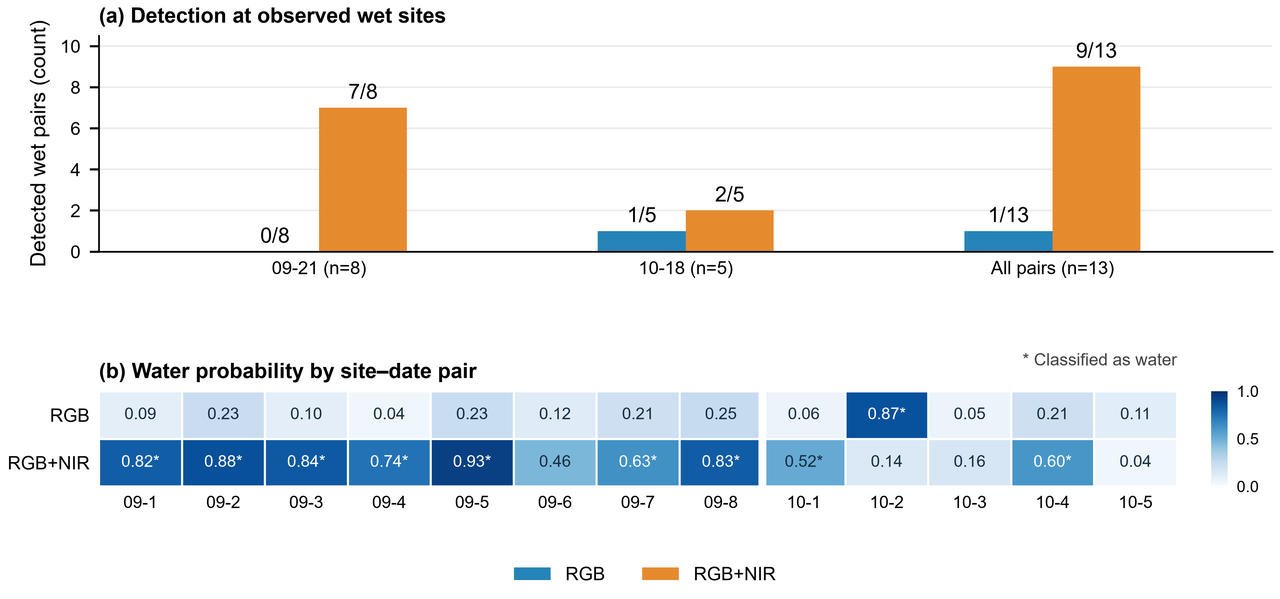

In [4]:
eligible = [r for r in matched if r['point_usable'] and r['flood_observation_supported']]
summary = []
for date in [*sorted({r['date'] for r in matched}), 'all']:
    subset = [r for r in eligible if date == 'all' or r['date'] == date]
    for model in ('rgb', 'rgb_nir'):
        detected = sum(r[f'{model}_prediction'] == 1 for r in subset)
        summary.append({'date': date, 'model': model, 'water_detections': detected,
                        'eligible_site_dates': len(subset), 'descriptive_fraction': detected / len(subset)})
show_table(summary)
save_csv('positive_site_summary.csv', summary)

# Compact comparison shared with the project Summary.
import sys, shutil
from IPython.display import Image
sys.path.insert(0, str(ROOT / 'scripts'))
from paper_figures import point_comparison
point_figure = point_comparison(matched)
shutil.copyfile(point_figure, OUT / 'point_comparison.png')
display(Image(filename=str(point_figure)))

## 5. Event profiles

Show all 13 published event sequences, with the catalog overpass at time zero. Curves connect the available discrete depth measurements; each panel retains the full recorded event.

In [5]:
fig, axes = plt.subplots(5, 3, figsize=(15, 14))
for ax, r, (_, seconds, depth, elapsed) in zip(axes.flat, matched, series):
    ax.plot((seconds - elapsed) / 60, depth, color='#009E73', linewidth=1.2)
    ax.axvline(0, color='0.4', linestyle='--', linewidth=1)
    ax.scatter([0], [r['depth_interpolated_cm']], color='#D55E00', s=18, zorder=3)
    ax.set_title(r['date'] + '\n' + r['sensor'], fontsize=9)
    ax.set(xlabel='Minutes from catalog overpass', ylabel='Depth (cm)')
    ax.grid(alpha=.2)
for ax in list(axes.flat)[len(matched):]:
    ax.remove()
fig.tight_layout()
fig.savefig(OUT / 'event_profiles.png', dpi=160, bbox_inches='tight')
plt.show()

[local output path]
  plt.show()


## 6. Input completeness and disagreement cases

Retain all 13 pairs in the main result. Report complete-center and complete-context subsets separately to describe missing-input sensitivity.

Three informative disagreements are September 161st (NIR probability about 0.459), October Davenport (about 25 cm measured depth, neither model predicts water), and October Brookville (RGB predicts water, NIR does not). The following panels show these actual exported cases.

input_subset,site_dates,rgb_detections,rgb_nir_detections
all usable sensor points,13,1,9
complete central window,12,1,8
complete 512 context and center,10,1,6


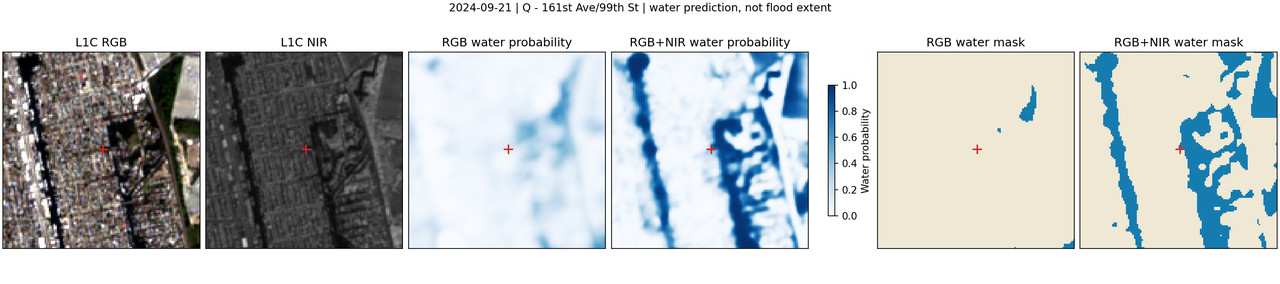

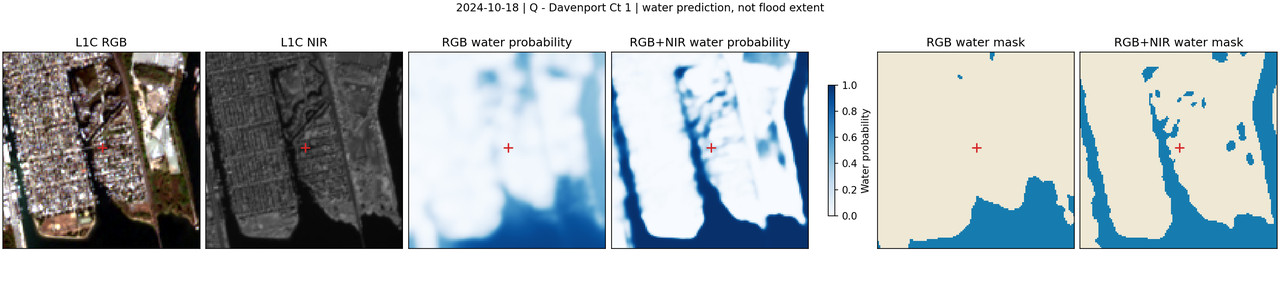

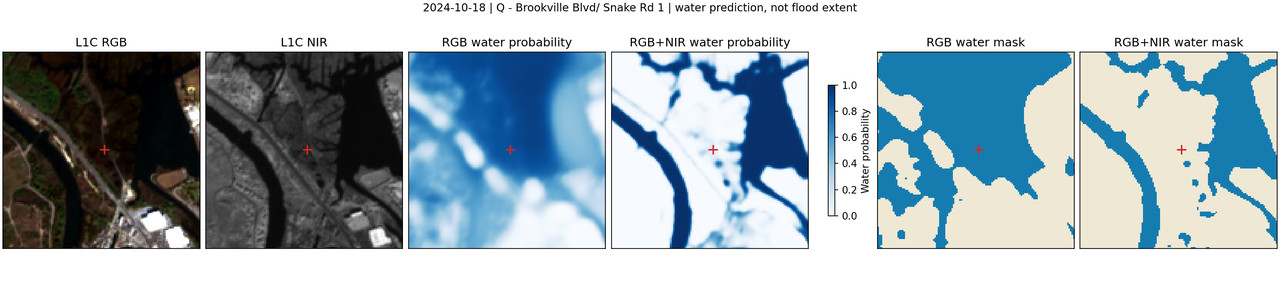

In [6]:
sensitivity = []
for label, subset in [
    ('all usable sensor points', eligible),
    ('complete central window', [r for r in eligible if r['center_usable_fraction'] == 1]),
    ('complete 512 context and center', [r for r in eligible if r['context_valid_fraction'] == 1 and r['center_usable_fraction'] == 1]),
]:
    sensitivity.append({'input_subset': label, 'site_dates': len(subset),
                        'rgb_detections': sum(r['rgb_prediction'] == 1 for r in subset),
                        'rgb_nir_detections': sum(r['rgb_nir_prediction'] == 1 for r in subset)})
show_table(sensitivity)
save_csv('input_completeness_summary.csv', sensitivity)
for date, sid in [('2024-09-21', 'Q-161st-ave-99th-st-1a5q80'),
                  ('2024-10-18', 'Q-davenport-ct-1-07zks0'),
                  ('2024-10-18', 'Q-brookville-blvd-rockaway-blvd-1-23ndo0')]:
    display(Image(filename=str(RUN / f'{date}_{sid}_comparison.png')))

## 7. Interpretation

RGB+NIR identifies water at more of the selected wet-site pixels, with clear variation across dates and locations. The comparison complements the public pixel-label evaluation. Observed dry controls and local pixel labels would be needed to assess NYC false positives and spatial segmentation accuracy.

The two wet dates are not a dry/flooded reference pair, and predicted water includes permanent water bodies.

In [7]:
totals = {r['model']: r for r in summary if r['date'] == 'all'}
report = f"""# NYC ground-observation comparison

{len(matched)} site–date pairs at {len({r['sensor_id'] for r in matched})} sites on two dates. All sensor pixels are usable and both bracketing depths exceed 1 cm. Measurement intervals are {min(r['bracket_gap_seconds'] for r in matched):.0f}–{max(r['bracket_gap_seconds'] for r in matched):.0f} seconds.

- RGB: {totals['rgb']['water_detections']}/{totals['rgb']['eligible_site_dates']} observed wet pairs classified as water.
- RGB+NIR: {totals['rgb_nir']['water_detections']}/{totals['rgb_nir']['eligible_site_dates']} observed wet pairs classified as water.
- Both models use Notebook 08 epoch-18 checkpoints; exported station values match the GeoTIFFs.

These are selected wet-site detections. NYC pixel accuracy requires independent spatial labels; predicted water includes permanent water bodies.

Outputs: point_matches.csv, positive_site_summary.csv, spatial_audit.csv, input_completeness_summary.csv, point_comparison.png and event_profiles.png.

Sources: [NYC event metadata](https://data.cityofnewyork.us/api/views/aq7i-eu5q.json) and [FloodNet methodology](https://www.floodnet.nyc/methodology).
"""
(OUT / 'summary.md').write_text(report, encoding='utf-8')
display(Markdown(report))
print('Saved:', OUT)

# NYC ground-observation comparison

13 site–date pairs at 10 sites on two dates. All sensor pixels are usable and both bracketing depths exceed 1 cm. Measurement intervals are 62–188 seconds.

- RGB: 1/13 observed wet pairs classified as water.
- RGB+NIR: 9/13 observed wet pairs classified as water.
- Both models use Notebook 08 epoch-18 checkpoints; exported station values match the GeoTIFFs.

These are selected wet-site detections. NYC pixel accuracy requires independent spatial labels; predicted water includes permanent water bodies.

Outputs: point_matches.csv, positive_site_summary.csv, spatial_audit.csv, input_completeness_summary.csv, point_comparison.png and event_profiles.png.

Sources: [NYC event metadata](https://data.cityofnewyork.us/api/views/aq7i-eu5q.json) and [FloodNet methodology](https://www.floodnet.nyc/methodology).


Saved: [local output path]
